<a href="https://colab.research.google.com/github/Madelavishnu/Pytorch/blob/main/MNIST_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [55]:
import torch
from torch import nn

import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

In [56]:
train_data = datasets.MNIST(root = "data",
                            train = True,
                            download = True,
                            transform=ToTensor(),
                            target_transform=None)
test_data = datasets.MNIST(root = "data",
                            train = False,
                            download = True,
                            transform=ToTensor())

In [57]:
!ls data/MNIST/raw

t10k-images-idx3-ubyte	   train-images-idx3-ubyte
t10k-images-idx3-ubyte.gz  train-images-idx3-ubyte.gz
t10k-labels-idx1-ubyte	   train-labels-idx1-ubyte
t10k-labels-idx1-ubyte.gz  train-labels-idx1-ubyte.gz


In [58]:
image , label = train_data[0]

In [59]:
image.shape, label

(torch.Size([1, 28, 28]), 5)

In [60]:
len(train_data), len(test_data)

(60000, 10000)

In [61]:
class_names = train_data.classes
class_names

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

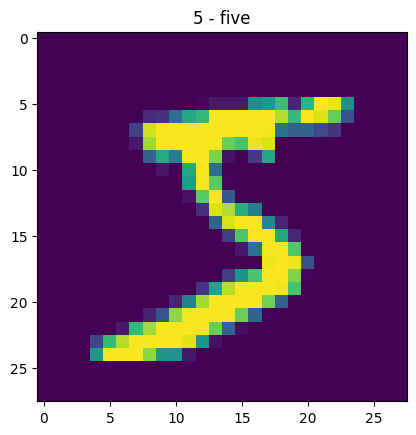

In [62]:
import matplotlib.pyplot as plt

plt.title(label)
plt.title(class_names[label])
plt.imshow(image.squeeze())

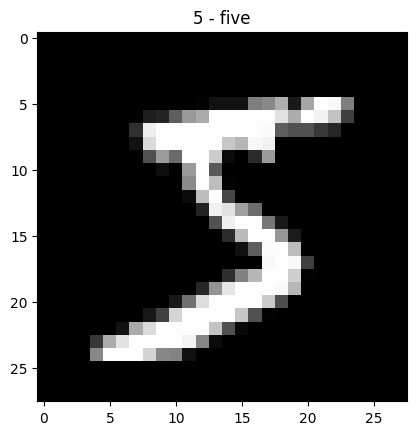

In [63]:
import matplotlib.pyplot as plt

plt.title(label)
plt.title(class_names[label])
plt.imshow(image.squeeze(),cmap = "gray")

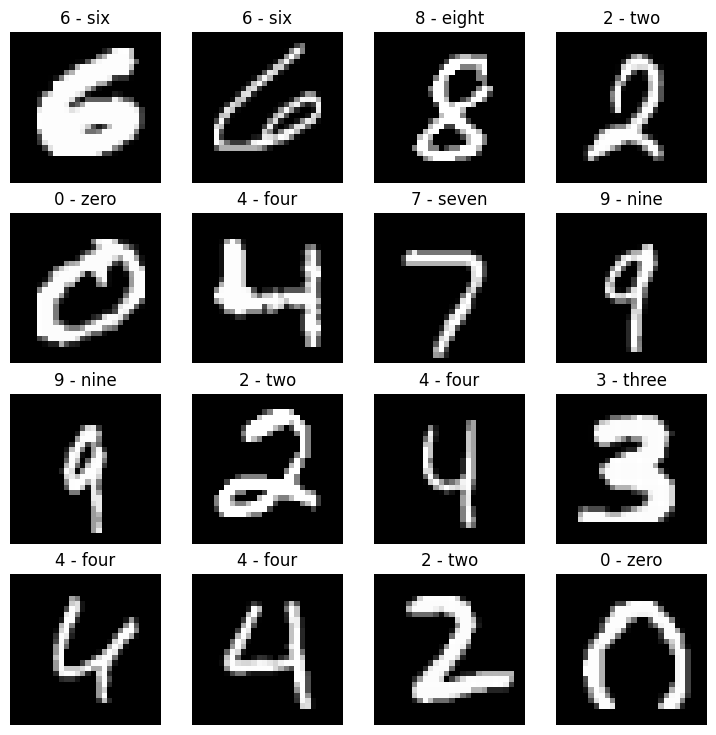

In [64]:
torch.manual_seed(42)
fig = plt.figure(figsize=(9, 9))

rows = 4
cols = 4

for i in range(1, rows * cols + 1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    img, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis(False);

In [65]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_data,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [66]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [67]:
import torch
from torch import nn

class MNIST_CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv_block = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),   # 28x28 → 14x14  # 28x28 → 14x14

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)               # 14x14 → 7x7
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 3 * 3, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv_block(x)
        x = self.classifier(x)
        return x
model_0 = MNIST_CNN().to(device)
model_0

MNIST_CNN(
  (conv_block): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=576, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)

In [68]:

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_0.parameters(), lr=0.01)

In [71]:
epochs = 5

for epoch in range(epochs):
    model_0.train()
    total_loss = 0

    for image, label in train_loader:
        image = image.to(device)
        label = label.to(device)

        preds = model_0(image)
        loss = loss_fn(preds, label)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 3266.7336
Epoch 2, Loss: 443.1373
Epoch 3, Loss: 231.3042
Epoch 4, Loss: 170.9429
Epoch 5, Loss: 139.7588


In [90]:
import torch.nn.functional as F

model_0.eval()

correct = 0
total = 0
rejected = 0

CONF_THRESHOLD = 0.75   # tune this

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model_0(images)
        probs = F.softmax(outputs, dim=1)

        confidences, predictions = probs.max(dim=1)

        for i in range(len(labels)):
            if confidences[i] < CONF_THRESHOLD:
                rejected += 1
            else:
                total += 1
                if predictions[i] == labels[i]:
                    correct += 1

if total > 0:
    accuracy = correct / total * 100
else:
    accuracy = 0

print(f"Accuracy (accepted only): {accuracy:.2f}%")
print(f"Rejected samples: {rejected}")
print(f"Rejection rate: {rejected / len(test_loader.dataset) * 100:.2f}%")


Accuracy (accepted only): 99.18%
Rejected samples: 350
Rejection rate: 3.50%


In [73]:
from torchvision import transforms

mnist_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((28, 28)),
    transforms.ToTensor()
])


In [85]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

def preprocess_mnist_image(image_path, device):
    # 1. Read image (grayscale)
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    # 2. Blur to remove noise
    img = cv2.GaussianBlur(img, (5, 5), 0)

    # 3. OTSU thresholding (robust binarization)
    _, img = cv2.threshold(
        img, 0, 255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    # 4. Find contours
    contours, _ = cv2.findContours(
        img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    # 5. Take the largest contour (the digit)
    contour = max(contours, key=cv2.contourArea)

    # 6. Bounding box
    x, y, w, h = cv2.boundingRect(contour)

    digit = img[y:y+h, x:x+w]

    # 7. Create square canvas
    size = max(w, h)
    canvas = np.zeros((size, size), dtype=np.uint8)

    # 8. Center digit in canvas
    x_offset = (size - w) // 2
    y_offset = (size - h) // 2
    canvas[y_offset:y_offset+h, x_offset:x_offset+w] = digit

    # 9. Resize to MNIST size
    canvas = cv2.resize(canvas, (28, 28))

    # 10. Normalize
    canvas = canvas.astype(np.float32) / 255.0

    # 11. Convert to tensor
    canvas = torch.tensor(canvas)

    # 12. Add channel & batch dimensions
    canvas = canvas.unsqueeze(0).unsqueeze(0)

    # 13. Move to device
    canvas = canvas.to(device)

    return canvas


In [86]:
model_0.eval()

img_tensor1 = preprocess_mnist_image("/content/WhatsApp Image 2025-12-28 at 12.27.00 PM.jpeg",device)
with torch.no_grad():
    output = model_0(img_tensor1)
    pred = output.argmax(dim=1).item()

print("Predicted digit:", pred)


Predicted digit: 5


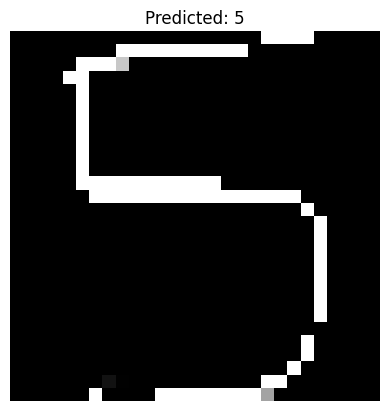

In [87]:
import matplotlib.pyplot as plt

plt.imshow(img_tensor1.cpu().squeeze(), cmap="gray")
plt.title(f"Predicted: {pred}")
plt.axis("off")
plt.show()


In [88]:
model_0.eval()
img_tensor = preprocess_mnist_image("/content/WhatsApp Image 2025-12-27 at 3.33.46 PM.jpeg",device)
with torch.no_grad():
    output = model_0(img_tensor)
    pred = output.argmax(dim=1).item()

print("Predicted digit:", pred)

Predicted digit: 4


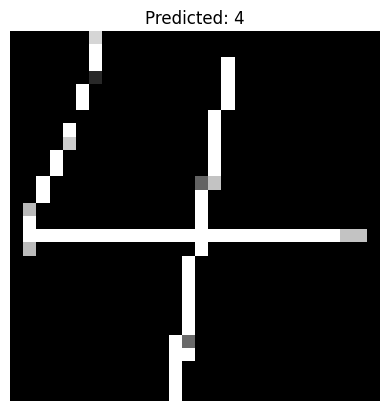

In [89]:
import matplotlib.pyplot as plt

plt.imshow(img_tensor.cpu().squeeze(), cmap="gray")
plt.title(f"Predicted: {pred}")
plt.axis("off")
plt.show()
